# Main in notebook
**To visualize the outputs**

## Celda 1: Entrenamiento y Setup
Esta celda replica la lógica de tu script para tener el modelo vivo dentro del entorno interactivo.

In [1]:
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#mis .py
from src.data_processing import DataProcessor
from src.decision_tree import DecisionTree

json_files = glob.glob("data/Streaming_History_Audio_2026*.json")
processor = DataProcessor(json_paths=json_files)
X, y = processor.process()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Entrenando Árbol de Decisión desde cero...")
arbol = DecisionTree(max_depth=5, min_samples_split=5, criterion="gini")
arbol.fit(X_train, y_train)

# Predecir
y_pred = arbol.predict(X_test)
print(f"¡Entrenamiento completado! Accuracy: {accuracy_score(y_test, y_pred):.2%}")

Entrenando Árbol de Decisión desde cero...
¡Entrenamiento completado! Accuracy: 83.19%


## Celda 2: La Matriz de Confusión
Aquí usamos seaborn para generar un mapa de calor presentable y profesional, cumpliendo con la rúbrica sobre la matriz y las métricas.

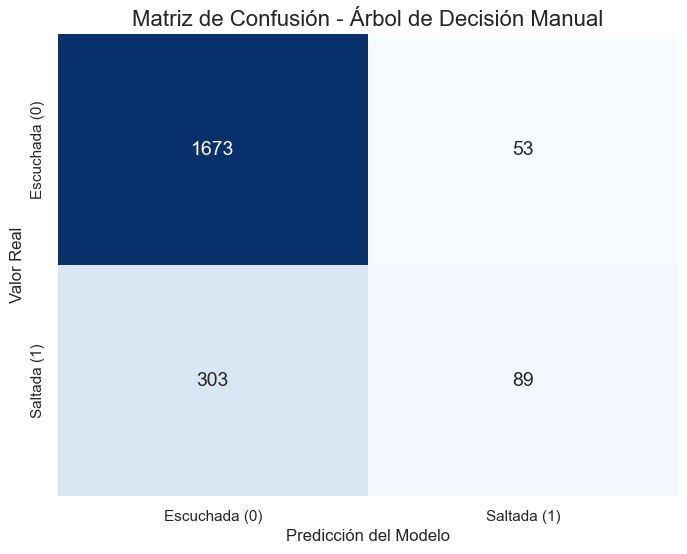


Metricas de la matriz
              precision    recall  f1-score   support

           0       0.85      0.97      0.90      1726
           1       0.63      0.23      0.33       392

    accuracy                           0.83      2118
   macro avg       0.74      0.60      0.62      2118
weighted avg       0.81      0.83      0.80      2118



In [2]:
%matplotlib inline

# Configuración visual
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (8, 6)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Escuchada (0)', 'Saltada (1)'],
            yticklabels=['Escuchada (0)', 'Saltada (1)'],
            annot_kws={"size": 14})

plt.title('Matriz de Confusión - Árbol de Decisión Manual', fontsize=16)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.show()

# Reporte de métricas (Precision, Recall, F1-Score)
print("\nMetricas de la matriz")
print(classification_report(y_test, y_pred))

## Celda 3: Visualización Nativa de tu Árbol (La Joya de la Corona)

In [3]:
def imprimir_arbol(nodo, feature_names, espaciado=""):
    """
    Función recursiva para imprimir el árbol de decisión en formato de texto.
    Lee los objetos Node nativos de nuestra clase DecisionTree.
    """
    if nodo is None:
        return

    info_matematica = ""
    if nodo.gini is not None and nodo.samples is not None:
        info_matematica = f"(gini: {nodo.gini:.3f} | samples: {nodo.samples})"

    if nodo.is_leaf():
        clase_str = "Saltada (1)" if nodo.value == 1 else "Escuchada (0)"
        print(f"{espaciado} └── Predicción: {clase_str} {info_matematica}")
        return

    nombre_feature = feature_names[nodo.feature_index]
    umbral = nodo.threshold

    print(f"{espaciado} ├── ¿{nombre_feature} <= {umbral:.2f}? {info_matematica}")
    
    print(f"{espaciado} │   ├── [SÍ]")
    imprimir_arbol(nodo.left, feature_names, espaciado + " │   ")
    
    print(f"{espaciado} │   └── [NO]")
    imprimir_arbol(nodo.right, feature_names, espaciado + "     ")

print("árbol de decisión\n")
imprimir_arbol(arbol.root, processor.feature_names)

árbol de decisión

 ├── ¿reason_start_trackdone <= 0.00? (gini: 0.302 | samples: 8471)
 │   ├── [SÍ]
 │    ├── ¿master_metadata_album_artist_name <= 43.00? (gini: 0.497 | samples: 2029)
 │    │   ├── [SÍ]
 │    │    ├── ¿platform_ios <= 0.00? (gini: 0.475 | samples: 617)
 │    │    │   ├── [SÍ]
 │    │    │    ├── ¿hour <= 11.00? (gini: 0.475 | samples: 98)
 │    │    │    │   ├── [SÍ]
 │    │    │    │    ├── ¿master_metadata_album_artist_name <= 2.00? (gini: 0.500 | samples: 60)
 │    │    │    │    │   ├── [SÍ]
 │    │    │    │    │    └── Predicción: Saltada (1) (gini: 0.346 | samples: 9)
 │    │    │    │    │   └── [NO]
 │    │    │    │         └── Predicción: Escuchada (0) (gini: 0.495 | samples: 51)
 │    │    │    │   └── [NO]
 │    │    │         ├── ¿master_metadata_album_artist_name <= 11.00? (gini: 0.332 | samples: 38)
 │    │    │         │   ├── [SÍ]
 │    │    │         │    └── Predicción: Escuchada (0) (gini: 0.490 | samples: 14)
 │    │    │         │   └── [NO]
 │